# Correcting quantum errors

### Classical encoding and decoding
suppose we have a 3 bit repetition encoder, 1 become 111 and 0 become 000. The value of the received bit become the value of the majority of the packet value. 

In [2]:
import numpy as np

In [3]:
inputValue = 0
repetition = 3

received = np.random.randint(0,2,repetition)
majority = list(received).count(inputValue)
if majority > np.floor(repetition/2):
    print("input bit: ", inputValue, "received : ", received, "Majority OK")
else:
    print("input bit: ", inputValue, "received : ", received, "Not OK")

input bit:  0 received :  [1 1 0] Not OK


### Noise reduction for the binary symmetric channel
For an example of a situation in which the chances of making an error can be decreased using a repetition code, suppose that our goal is to communicate a single bit to a hypothetical receiver, and we're able to transmit bits through a so-called binary symmetric channel, which flips each bit sent through it independently with some probability $p$. That is, with probability $1-p$, the receiver gets whatever bit was sent through the channel, but with probability $p$ the bit-flips and the receiver gets the opposite bit value.

So, if we choose not to use the 3-bit repetition code, and simply send whatever bit we have in mind through the channel, the receiver therefore receives the wrong bit with probability $p$ On the other hand, if we first encode the bit we want to send using the 3-bit repetition code, and then send each of the three bits of the encoding through the channel, then each one of them flips independently with probability $p$. The chances of a bit-flip are now greater because there are now three bits that might flip rather than one, but if at most one of the bits flips, then the receiver will decode correctly. An error therefore persists after decoding only if two or more of the bits flip during transmission.

The probability that two bits flip during transmission is $3p^2(1-p)$, which is $p^2(1-p)$
for each of the three choices for the bit that doesn't flip, while the probability that all three bits flip is $p^3$. The total probability of two or three bit-flips is therefore
$$ 3p^2(1-p)+p^3 = 3p^2-2p^3$$

For values of $p$ smaller than one-half, this results in a decrease in the probability that the receiver ends up with the wrong bit. There will still be a chance of an error in this case, but the code decreases the likelihood. (For values of $p$
greater than one-half, on the other hand, the code actually increases the likelihood that the receiver gets the wrong bit.)

In [4]:
p = np.linspace(0,1,num=256)
error_prob = 3*p**2-2*p**3

<function matplotlib.pyplot.grid(visible: 'bool | None' = None, which: "Literal['major', 'minor', 'both']" = 'major', axis: "Literal['both', 'x', 'y']" = 'both', **kwargs) -> 'None'>

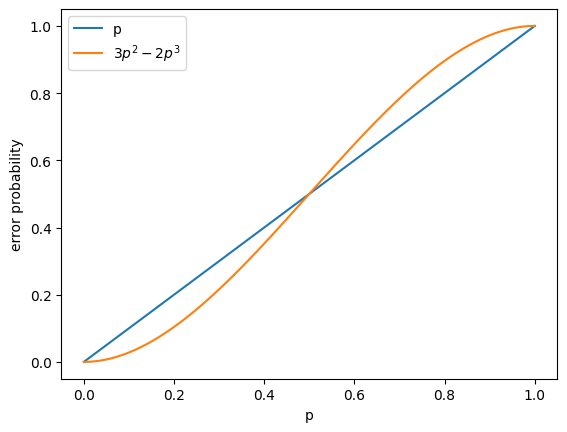

In [5]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(p, p, label = "p")
plt.plot(p, error_prob, label = "$3p^2-2p^3$")
plt.ylabel("error probability")
plt.xlabel("p")
plt.legend()
plt.grid

### Encoding qubits

In [6]:
from qiskit.quantum_info import Statevector
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
from qiskit.circuit import Parameter

'input : '

<IPython.core.display.Latex object>

'output : '

<IPython.core.display.Latex object>

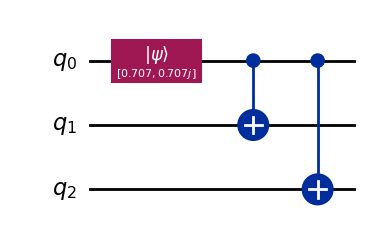

In [7]:
alpha =  1/np.sqrt(2)
beta = 1j/np.sqrt(2)
sv = Statevector([alpha, beta])
display("input : ", sv.draw("latex"))

qc = QuantumCircuit(3)
# initialisation etat q0
qc.initialize(sv, 0)

# apply cx gates
qc.cx(0,1)
qc.cx(0,2)


display("output : ", Statevector.from_instruction(qc).draw("latex"))
qc.draw("mpl")

### Bit-flip errors

In [8]:
# add register for the measure
qr = QuantumRegister(2)
cr = ClassicalRegister(2)
qc.add_register(qr)
qc.add_register(cr)
qc.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=5, num_clbits=0, params=[]), qubits=(<Qubit register=(3, "q"), index=0>, <Qubit register=(3, "q"), index=1>, <Qubit register=(3, "q"), index=2>, <Qubit register=(2, "q0"), index=0>, <Qubit register=(2, "q0"), index=1>), clbits=())

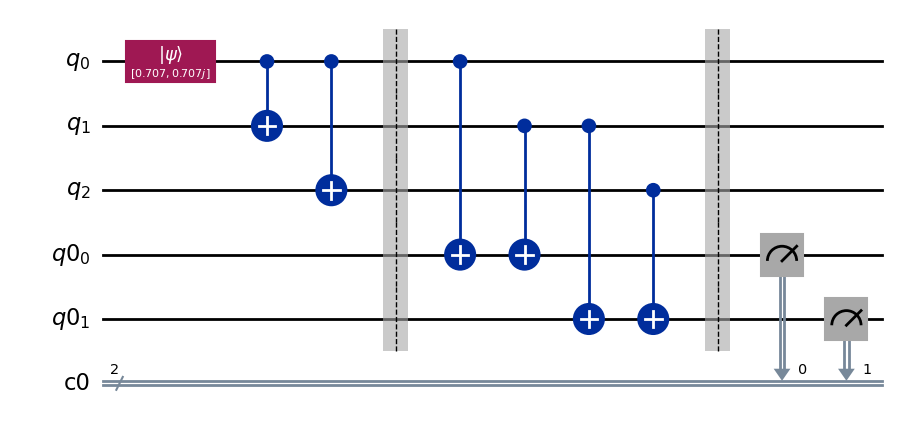

In [9]:
qc.cx(0, qr[0])
qc.cx(1, qr[0])
qc.cx(1, qr[1])
qc.cx(2, qr[1])
qc.barrier()

# measure
qc.measure(qr, cr)
qc.draw("mpl")

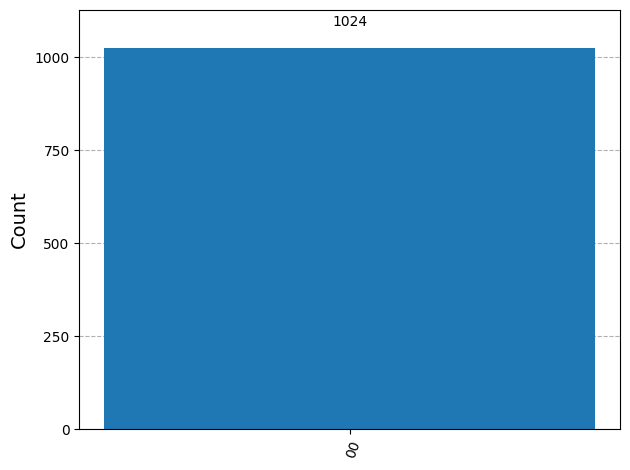

In [10]:
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()
job = sim.run(qc).result()

plot_histogram(job.get_counts())

'input : '

<IPython.core.display.Latex object>

'output : '

<IPython.core.display.Latex object>

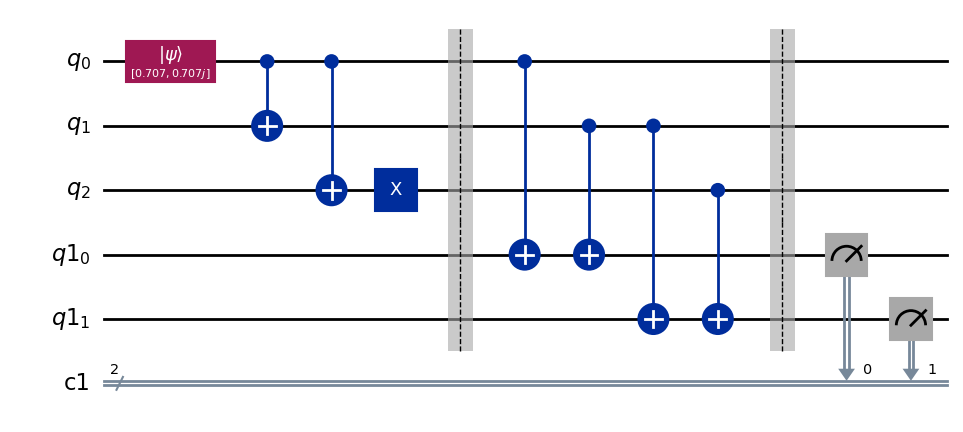

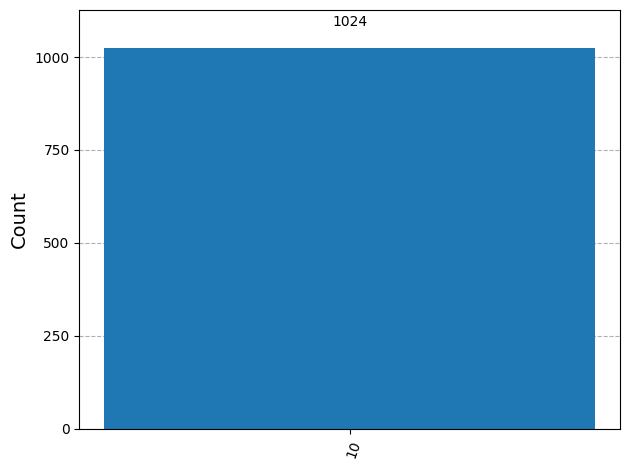

In [11]:
# same but we apply a bit flip on one of the third qubit 

alpha =  1/np.sqrt(2)
beta = 1j/np.sqrt(2)
sv = Statevector([alpha, beta])
display("input : ", sv.draw("latex"))

qc = QuantumCircuit(3)
# initialisation etat q0
qc.initialize(sv, 0)

# apply cx gates
qc.cx(0,1)
qc.cx(0,2)


display("output : ", Statevector.from_instruction(qc).draw("latex"))
qc.draw("mpl")

# add register for the measure
qr = QuantumRegister(2)
cr = ClassicalRegister(2)
qc.add_register(qr)
qc.add_register(cr)

# add x bit flip
#qc.x(0)
#qc.x(1)
qc.x(2)

qc.barrier()

qc.cx(0, qr[0])
qc.cx(1, qr[0])
qc.cx(1, qr[1])
qc.cx(2, qr[1])
qc.barrier()

# measure
qc.measure(qr, cr)
display(qc.draw("mpl"))

sim = AerSimulator()
job = sim.run(qc).result()

plot_histogram(job.get_counts())

### Phase Flip error

'input : '

<IPython.core.display.Latex object>

'output : '

<IPython.core.display.Latex object>

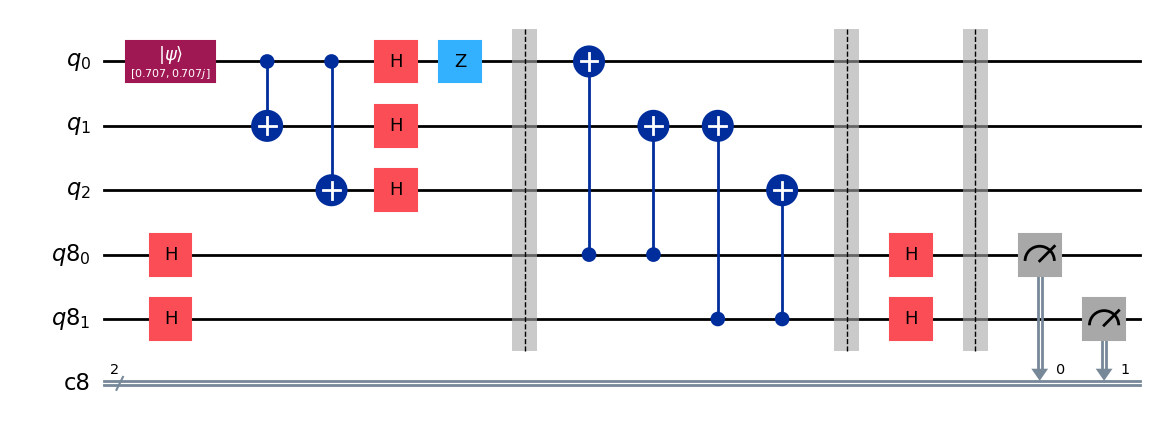

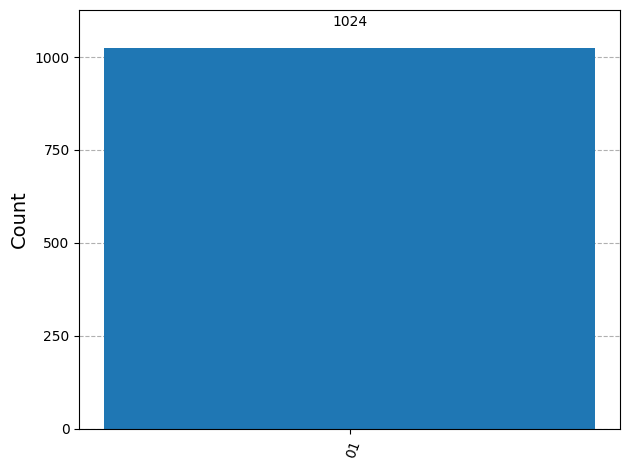

In [18]:
# same but we apply a bit flip on one of the third qubit 

alpha =  1/np.sqrt(2)
beta = 1j/np.sqrt(2)
sv = Statevector([alpha, beta])
display("input : ", sv.draw("latex"))

qc = QuantumCircuit(3)
# initialisation etat q0
qc.initialize(sv, 0)

# apply cx gates
qc.cx(0,1)
qc.cx(0,2)

qc.h(range(3))


display("output : ", Statevector.from_instruction(qc).draw("latex"))
qc.draw("mpl")

# add register for the measure
qr = QuantumRegister(2)
cr = ClassicalRegister(2)
qc.add_register(qr)
qc.add_register(cr)
qc.h(qr)



# add z bit flip
qc.z(0)


qc.barrier()

qc.cx(qr[0], 0)
qc.cx(qr[0], 1)
qc.cx(qr[1], 1)
qc.cx(qr[1], 2)
qc.barrier()
qc.h(qr)
qc.barrier()
# hadamard gates
# measure
qc.measure(qr, cr)
display(qc.draw("mpl"))

sim = AerSimulator()
job = sim.run(qc).result()

plot_histogram(job.get_counts())

### The 9 qubit Shor code
correction for phase flip and bit flip errors

In [34]:
subcirc = QuantumCircuit(3)
subcirc.cx(0,1)
subcirc.cx(0,2)
block = subcirc.to_gate(label="subcirc")

'input : '

<IPython.core.display.Latex object>

'output : '

<IPython.core.display.Latex object>

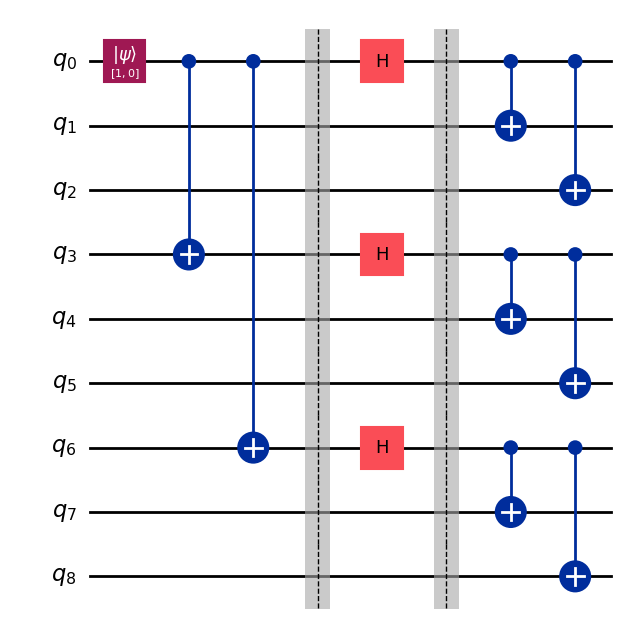

In [40]:

alpha =  1
beta = 0#1j/np.sqrt(2)
sv = Statevector([alpha, beta])
display("input : ", sv.draw("latex"))

circuit = QuantumCircuit(9)
circuit.initialize(sv, 0)

# phase flip detection
circuit.cx(0,3)
circuit.cx(0,6)
circuit.barrier()
circuit.h([0,3,6])
circuit.barrier()

# bit flip correction
circuit.append(block, range(0,3))
circuit.append(block, range(3,6))
circuit.append(block, range(6,9))

display("output : ", Statevector.from_instruction(circuit).draw("latex"))

display(circuit.decompose(gates_to_decompose="subcirc").draw("mpl"))

### Correcting bit flip and phase flip
#### Errors and CNOT gates

'State before Barrier() :'

<IPython.core.display.Latex object>

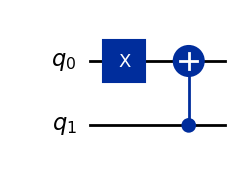

'Equivalent :'

<IPython.core.display.Latex object>

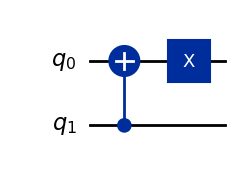

In [60]:
# correcting composition of CNOT and X gates
c1 = QuantumCircuit(2)
c1.x(0)
c1.cx(1,0)
display("State before Barrier() :", Statevector.from_instruction(c1).draw("latex"))
display(c1.draw("mpl"))

c2 = QuantumCircuit(2)
c2.cx(1,0)
c2.x(0)
display("Equivalent :", Statevector.from_instruction(c2).draw("latex"))
display(c2.draw("mpl"))



'State before Barrier() :'

<IPython.core.display.Latex object>

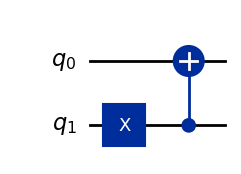

'Equivalent :'

<IPython.core.display.Latex object>

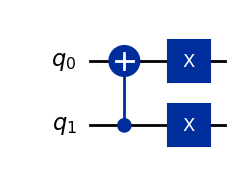

In [61]:
# correcting composition of CNOT and X gates
c1 = QuantumCircuit(2)
c1.x(1)
c1.cx(1,0)
display("State before Barrier() :", Statevector.from_instruction(c1).draw("latex"))
display(c1.draw("mpl"))

c2 = QuantumCircuit(2)
c2.cx(1,0)
c2.x(0)
c2.x(1)
display("Equivalent :", Statevector.from_instruction(c2).draw("latex"))
display(c2.draw("mpl"))



'State before Barrier() :'

<IPython.core.display.Latex object>

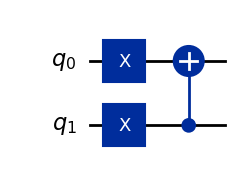

'Equivalent :'

<IPython.core.display.Latex object>

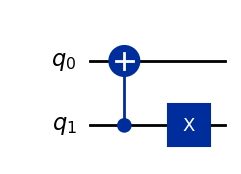

In [63]:
# correcting composition of CNOT and X gates
c1 = QuantumCircuit(2)
c1.x(0)
c1.x(1)
c1.cx(1,0)
display("State before Barrier() :", Statevector.from_instruction(c1).draw("latex"))
display(c1.draw("mpl"))

c2 = QuantumCircuit(2)
c2.cx(1,0)
c2.x(1)
display("Equivalent :", Statevector.from_instruction(c2).draw("latex"))
display(c2.draw("mpl"))



'State before Barrier() :'

<IPython.core.display.Latex object>

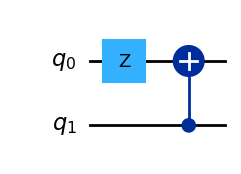

'Equivalent :'

<IPython.core.display.Latex object>

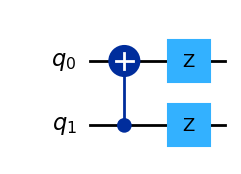

In [65]:
# correcting composition of CNOT and X gates
c1 = QuantumCircuit(2)
c1.z(0)
c1.cx(1,0)
display("State before Barrier() :", Statevector.from_instruction(c1).draw("latex"))
display(c1.draw("mpl"))

c2 = QuantumCircuit(2)
c2.cx(1,0)
c2.z(0)
c2.z(1)
display("Equivalent :", Statevector.from_instruction(c2).draw("latex"))
display(c2.draw("mpl"))



'State before Barrier() :'

<IPython.core.display.Latex object>

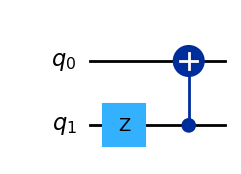

'Equivalent :'

<IPython.core.display.Latex object>

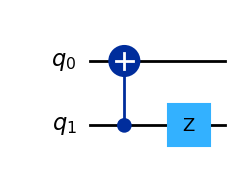

In [66]:
# correcting composition of CNOT and X gates
c1 = QuantumCircuit(2)
c1.z(1)
c1.cx(1,0)
display("State before Barrier() :", Statevector.from_instruction(c1).draw("latex"))
display(c1.draw("mpl"))

c2 = QuantumCircuit(2)
c2.cx(1,0)
c2.z(1)
display("Equivalent :", Statevector.from_instruction(c2).draw("latex"))
display(c2.draw("mpl"))

'State before Barrier() :'

<IPython.core.display.Latex object>

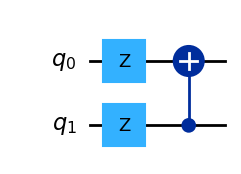

'Equivalent :'

<IPython.core.display.Latex object>

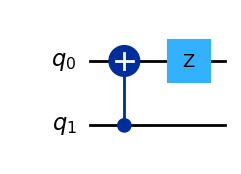

In [67]:
# correcting composition of CNOT and X gates
c1 = QuantumCircuit(2)
c1.z(0)
c1.z(1)
c1.cx(1,0)
display("State before Barrier() :", Statevector.from_instruction(c1).draw("latex"))
display(c1.draw("mpl"))

c2 = QuantumCircuit(2)
c2.cx(1,0)
c2.z(0)
display("Equivalent :", Statevector.from_instruction(c2).draw("latex"))
display(c2.draw("mpl"))
